In [1]:
!pip install ColabTurtle

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for ColabTurtle: filename=colabturtle-2.1.0-py3-none-any.whl size=7675 sha256=bbece36242c080b0a0ee06e7d7da6feb521b68aff56e53dfa784f057e84029cf
  Stored in directory: /home/codespace/.cache/pip/wheels/9f/af/64/ffd85f9858ed7d56b7293dcedbc9d461bf13c8cfc97e352bc8
Successfully built ColabTurtle

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [12]:
%reset -f
x1, y1 = 20, 10
x2, y2 = 30, 5

assert 0 <= x1 <= 511 and 0 <= y1 <= 511
assert 0 <= x2 <= 511 and 0 <= y2 <= 511
print(f'キャラ位置 -> X:{x1:3}  Y:{y1:3}')
print(f'幽霊船位置 -> X:{x2:3}  Y:{y2:3}')
print()

# ▼▼▼ ここから

W = 512  # フィールドの幅・高さ

def ghost_ship_direction(x1, y1, x2, y2):
    """自キャラ(x1,y1)から幽霊船(x2,y2)への方向メッセージを返す"""
    # 同じ座標なら特殊メッセージ
    if x1 == x2 and y1 == y2:
        return "💀「幽霊船にであえたようじゃな」"

    # 東西の移動量を計算
    east = (x2 - x1) % W
    west = (x1 - x2) % W

    # 南北の移動量を計算
    south = (y2 - y1) % W
    north = (y1 - y2) % W

    # 東西方向の決定（east <= west なら東、ただし0の場合は含めない）
    ew_msg = ""
    if east <= west:
        if east != 0:
            ew_msg = f"東に{east}"
    else:
        if west != 0:
            ew_msg = f"西に{west}"

    # 南北方向の決定（south <= north なら南、ただし0の場合は含めない）
    ns_msg = ""
    if south <= north:
        if south != 0:
            ns_msg = f"南に{south}"
    else:
        if north != 0:
            ns_msg = f"北に{north}"

    # メッセージの組み立て（読点に注意）
    if ew_msg and ns_msg:
        body = f"{ew_msg}、{ns_msg}進めば幽霊船にであえるだろう"
    elif ew_msg:
        body = f"{ew_msg}進めば幽霊船にであえるだろう"
    else:
        body = f"{ns_msg}進めば幽霊船にであえるだろう"

    return f"💀「{body}」"


print(ghost_ship_direction(x1, y1, x2, y2))

キャラ位置 -> X: 20  Y: 10
幽霊船位置 -> X: 30  Y:  5

💀「東に10、北に5進めば幽霊船にであえるだろう」


In [5]:
!pip install japanize_matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 49.5 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 45.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 54.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 40.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 56.5 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 45.0 MB/s  0:00:00
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120306 sha256=c9146bf1ee14ff32defcc55b0b7fefca18d2170214030020c241ee58bb7144a0
  Stored in directory: /home/codespace/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize_matplotlib
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [japanize_matplotlib]tplot

Miss.


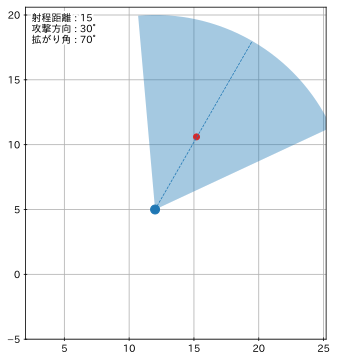

In [10]:
%reset -f
import math
import japanize_matplotlib
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib import patches
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')
plt.rcParams['mathtext.fontset'] = 'cm'

# ▼▼▼ 基本的な書き換え範囲（ここから）

# 自キャラ位置
x1 = 12.0
y1 = 5.0

# 敵キャラ位置
x2 = 15.2
y2 = 10.6

# 射程距離、攻撃方向、拡がり角
bw_range = 15
bw_direction = 30
bw_spread_angle = 70

# 判定処理
print('Miss.')

# ▲▲▲ 基本的な書き換え範囲（ここまで）

assert -128 <= x1 <= 127  
assert -128 <= y1 <= 127  
assert -128 <= x2 <= 127  
assert -128 <= y2 <= 127  
assert 0.5 <= bw_range <= 50
assert -180 <= bw_direction <= 180
assert 5 <= bw_spread_angle <= 270

# 以下、適切に「当たり判定」ができているかを確認するための処理です。
# 現時点では深く理解する必要はありません

def render_graph():

  xp = x1+math.cos(math.radians(-bw_direction+90))*bw_range
  yp = y1+math.sin(math.radians(-bw_direction+90))*bw_range

  fig,ax=plt.subplots(figsize=(6,6), facecolor='white', dpi=96)
  ax.scatter(x1,y1,c='tab:blue',s=80)

  ax.plot([x1,xp],[y1,yp],ls='--',lw=0.75)
  ax.set_aspect('equal', adjustable='box')
  margin = 10
  ax.set_xlim( min(x1,x2)-margin, max(x1,x2)+margin )
  ax.set_ylim( min(y1,y2)-margin, max(y1,y2)+margin )

  sector = patches.Wedge((x1,y1),bw_range,
                        -bw_direction - bw_spread_angle/2 + 90,
                        -bw_direction + bw_spread_angle/2 + 90,
                        width=bw_range, alpha=0.4)
  ax.add_patch(sector)

  ax.scatter(x2,y2,c='tab:red')
  t = ax.text(0.02, 0.98, f'射程距離 : {bw_range}\n攻撃方向 : {bw_direction}°\n拡がり角 : {bw_spread_angle}°',
          va='top', ha='left', transform=ax.transAxes)
  t.set_path_effects([pe.Stroke(linewidth=4,foreground='white'),pe.Normal()])

  ax.grid()
  ax.set_axisbelow(True)
  ax.tick_params(direction='inout')
  plt.show()

render_graph()